In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/diabetic-retinopathy-detection/train.zip.003
/kaggle/input/competitions/diabetic-retinopathy-detection/test.zip.004
/kaggle/input/competitions/diabetic-retinopathy-detection/test.zip.005
/kaggle/input/competitions/diabetic-retinopathy-detection/train.zip.002
/kaggle/input/competitions/diabetic-retinopathy-detection/test.zip.006
/kaggle/input/competitions/diabetic-retinopathy-detection/test.zip.003
/kaggle/input/competitions/diabetic-retinopathy-detection/train.zip.005
/kaggle/input/competitions/diabetic-retinopathy-detection/train.zip.001
/kaggle/input/competitions/diabetic-retinopathy-detection/sampleSubmission.csv.zip
/kaggle/input/competitions/diabetic-retinopathy-detection/test.zip.007
/kaggle/input/competitions/diabetic-retinopathy-detection/trainLabels.csv.zip
/kaggle/input/competitions/diabetic-retinopathy-detection/test.zip.001
/kaggle/input/competitions/diabetic-retinopathy-detection/sample.zip
/kaggle/input/competitions/diabetic-retinopathy-detectio

**Install & Verify packages******

In [1]:
import subprocess, sys

def pip(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

pip("timm")

import os, cv2, math, shutil, random
from pathlib import Path
from tqdm import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from sklearn.metrics import (accuracy_score, confusion_matrix,
                              classification_report)

print("✓ All packages imported")
print(f"  PyTorch  : {torch.__version__}")
print(f"  CUDA     : {torch.cuda.is_available()}")




✓ All packages imported
  PyTorch  : 2.10.0+cu128
  CUDA     : True


In [2]:
KAGGLE_INPUT  = "/kaggle/input/competitions/diabetic-retinopathy-detection"
WORKING       = "/kaggle/working"

FIRST_PART    = f"{KAGGLE_INPUT}/train.zip.001"
TEMP_DIR      = f"{WORKING}/temp_extract"
OUTPUT_DIR    = f"{WORKING}/train_images_compressed"
LABELS_CSV    = f"{KAGGLE_INPUT}/trainLabels.csv"

PROJECT_DIR   = Path(f"{WORKING}/SplitDATA")
DATA_DIR      = PROJECT_DIR / "data"
CKPT_DIR      = PROJECT_DIR / "checkpoints"
LOG_DIR       = PROJECT_DIR / "logs"

TARGET_SIZE   = (224, 224)
JPEG_QUALITY  = 75
CHUNK_SIZE    = 3000

BATCH_SIZE    = 32
NUM_EPOCHS    = 12
LR            = 1e-4
WEIGHT_DECAY  = 1e-4
PATIENCE      = 10
DROPOUT       = 0.3
NUM_CLASSES   = 5
SEED          = 42

CLASS_NAMES   = ["No DR", "Mild", "Moderate", "Severe", "Proliferative DR"]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")
if device.type == "cuda":
    print(f"  GPU  : {torch.cuda.get_device_name(0)}")
    print(f"  VRAM : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")



Device : cuda
  GPU  : Tesla T4
  VRAM : 15.6 GB


In [3]:
for split in ["train", "val", "test"]:
    for cls in range(NUM_CLASSES):
        (DATA_DIR / split / str(cls)).mkdir(parents=True, exist_ok=True)

CKPT_DIR.mkdir(parents=True, exist_ok=True)
LOG_DIR.mkdir(parents=True, exist_ok=True)
Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)
Path(TEMP_DIR).mkdir(parents=True, exist_ok=True)

print("✓ Folder structure created")
for split in ["train", "val", "test"]:
    print(f"  SplitDATA/data/{split}/{{0,1,2,3,4}}/")


✓ Folder structure created
  SplitDATA/data/train/{0,1,2,3,4}/
  SplitDATA/data/val/{0,1,2,3,4}/
  SplitDATA/data/test/{0,1,2,3,4}/


In [6]:
def run_cmd(cmd):
    result = subprocess.run(cmd, capture_output=True, text=True)
    return result.returncode, result.stdout, result.stderr

def clear_dir(path):
    if os.path.exists(path):
        shutil.rmtree(path)
    os.makedirs(path, exist_ok=True)

def count_images(folder):
    total = 0
    for _, _, files in os.walk(folder):
        total += sum(f.lower().endswith((".jpg", ".jpeg", ".png")) for f in files)
    return total

def show_disk():
    code, out, err = run_cmd(["df", "-h", WORKING])
    print(out if out else err)



In [7]:
print("=== Step 1: Reading archive listing ===")
code, out, err = run_cmd(["7z", "l", FIRST_PART])
if code != 0:
    print("ERROR: Cannot list archive — check FIRST_PART path")
    print(err)
    raise SystemExit

# Parse image filenames from the 7z listing output
image_files = []
for line in out.splitlines():
    line = line.strip()
    if not line:
        continue
    if line.lower().endswith((".jpeg", ".jpg", ".png")):
        parts = line.split()
        fname = parts[-1]
        if fname.startswith("train/"):
            image_files.append(fname)

# Deduplicate
seen = set()
image_files = [x for x in image_files if not (x in seen or seen.add(x))]

print(f"  Total images found in archive : {len(image_files)}")
print(f"  Sample                        : {image_files[:3]}")

if len(image_files) == 0:
    print("ERROR: No images parsed from archive listing.")
    raise SystemExit

# Quick 2-image extraction test
print("\n=== Step 2: Quick extraction test ===")
clear_dir(TEMP_DIR)
code, out, err = run_cmd(["7z", "x", FIRST_PART, f"-o{TEMP_DIR}", "-y"] + image_files[:2])
test_imgs = list(Path(TEMP_DIR).rglob("*.jpg")) + list(Path(TEMP_DIR).rglob("*.jpeg"))
print(f"  Test extracted: {len(test_imgs)} images  (expect 2)")
if len(test_imgs) == 0:
    print("ERROR: Test extraction failed."); raise SystemExit
clear_dir(TEMP_DIR)

# Chunked bulk processing
num_chunks = math.ceil(len(image_files) / CHUNK_SIZE)
print(f"\n=== Step 3: Chunked extraction → resize → compress ===")
print(f"  Chunks     : {num_chunks}  (chunk size = {CHUNK_SIZE})")
print(f"  Target size: {TARGET_SIZE}, JPEG quality: {JPEG_QUALITY}")
print("  Initial disk state:")
show_disk()

total_ok, total_fail = 0, 0

for chunk_idx in range(num_chunks):
    start      = chunk_idx * CHUNK_SIZE
    end        = min(start + CHUNK_SIZE, len(image_files))
    chunk_list = image_files[start:end]

    print(f"\n  Chunk {chunk_idx+1}/{num_chunks}  |  files {start}–{end-1}")
    clear_dir(TEMP_DIR)

    code, out, err = run_cmd(["7z", "x", FIRST_PART, f"-o{TEMP_DIR}", "-y"] + chunk_list)
    if code != 0:
        print(f"  ✗ Extraction failed: {err[:400]}")
        total_fail += len(chunk_list)
        continue

    extracted = [p for p in Path(TEMP_DIR).rglob("*")
                 if p.suffix.lower() in (".jpg", ".jpeg", ".png")]
    print(f"  Extracted: {len(extracted)} images")

    ok_chunk, fail_chunk = 0, 0
    for img_path in tqdm(extracted, desc="  Compressing", leave=False):
        try:
            img = cv2.imread(str(img_path))
            if img is None:
                fail_chunk += 1; continue
            img = cv2.resize(img, TARGET_SIZE, interpolation=cv2.INTER_AREA)
            out_path = Path(OUTPUT_DIR) / (img_path.stem + ".jpg")
            ok = cv2.imwrite(str(out_path), img, [cv2.IMWRITE_JPEG_QUALITY, JPEG_QUALITY])
            if ok:
                ok_chunk += 1
            else:
                fail_chunk += 1
        except Exception:
            fail_chunk += 1

    total_ok   += ok_chunk
    total_fail += fail_chunk
    print(f"  ✓ Saved: {ok_chunk}  ✗ Failed: {fail_chunk}")
    print(f"  Total saved so far: {count_images(OUTPUT_DIR)}")
    clear_dir(TEMP_DIR)
    show_disk()

print(f"\n=== Extraction complete ===")
print(f"  Total processed : {total_ok}")
print(f"  Total failed    : {total_fail}")
print(f"  Output folder   : {OUTPUT_DIR}")




=== Step 1: Reading archive listing ===
  Total images found in archive : 35126
  Sample                        : ['train/10003_left.jpeg', 'train/10003_right.jpeg', 'train/10007_left.jpeg']

=== Step 2: Quick extraction test ===
  Test extracted: 2 images  (expect 2)

=== Step 3: Chunked extraction → resize → compress ===
  Chunks     : 12  (chunk size = 3000)
  Target size: (224, 224), JPEG quality: 75
  Initial disk state:
Filesystem      Size  Used Avail Use% Mounted on
/dev/loop1       20G  180K   20G   1% /kaggle/working


  Chunk 1/12  |  files 0–2999
  Extracted: 3000 images


  ✓ Saved: 3000  ✗ Failed: 0
  Total saved so far: 3000
Filesystem      Size  Used Avail Use% Mounted on
/dev/loop1       20G   22M   20G   1% /kaggle/working


  Chunk 2/12  |  files 3000–5999
  Extracted: 3000 images


  ✓ Saved: 3000  ✗ Failed: 0
  Total saved so far: 6000
Filesystem      Size  Used Avail Use% Mounted on
/dev/loop1       20G   43M   20G   1% /kaggle/working


  Chunk 3/12  |  files 6000–8999
  Extracted: 3000 images


  ✓ Saved: 3000  ✗ Failed: 0
  Total saved so far: 9000
Filesystem      Size  Used Avail Use% Mounted on
/dev/loop1       20G   65M   20G   1% /kaggle/working


  Chunk 4/12  |  files 9000–11999
  Extracted: 3000 images


  ✓ Saved: 3000  ✗ Failed: 0
  Total saved so far: 12000
Filesystem      Size  Used Avail Use% Mounted on
/dev/loop1       20G   86M   20G   1% /kaggle/working


  Chunk 5/12  |  files 12000–14999
  Extracted: 3000 images


...

  ✓ Saved: 3000  ✗ Failed: 0
  Total saved so far: 24000
Filesystem      Size  Used Avail Use% Mounted on
/dev/loop1       20G  171M   20G   1% /kaggle/working


  Chunk 9/12  |  files 24000–26999
  Extracted: 3000 images


  ✓ Saved: 3000  ✗ Failed: 0
  Total saved so far: 27000
Filesystem      Size  Used Avail Use% Mounted on
/dev/loop1       20G  192M   20G   1% /kaggle/working


  Chunk 10/12  |  files 27000–29999
  Extracted: 3000 images


  ✓ Saved: 3000  ✗ Failed: 0
  Total saved so far: 30000
Filesystem      Size  Used Avail Use% Mounted on
/dev/loop1       20G  213M   20G   2% /kaggle/working


  Chunk 11/12  |  files 30000–32999
  Extracted: 3000 images


  ✓ Saved: 3000  ✗ Failed: 0
  Total saved so far: 33000
Filesystem      Size  Used Avail Use% Mounted on
/dev/loop1       20G  234M   20G   2% /kaggle/working


  Chunk 12/12  |  files 33000–35125
  Extracted: 2126 images


  ✓ Saved: 2126  ✗ Failed: 0
  Total saved so far: 35126
Filesystem      Size  Used Avail Use% Mounted on
/dev/loop1       20G  250M   20G   2% /kaggle/working


=== Extraction complete ===
  Total processed : 35126
  Total failed    : 0
  Output folder   : /kaggle/working/train_images_compressed


In [16]:
import os

# Find the actual dataset path
for root, dirs, files in os.walk("/kaggle/input"):
    for file in files:
        print(os.path.join(root, file))

/kaggle/input/datasets/ani2599/trainlables/trainLabels (1).csv
/kaggle/input/competitions/diabetic-retinopathy-detection/train.zip.003
/kaggle/input/competitions/diabetic-retinopathy-detection/test.zip.004
/kaggle/input/competitions/diabetic-retinopathy-detection/test.zip.005
/kaggle/input/competitions/diabetic-retinopathy-detection/train.zip.002
/kaggle/input/competitions/diabetic-retinopathy-detection/test.zip.006
/kaggle/input/competitions/diabetic-retinopathy-detection/test.zip.003
/kaggle/input/competitions/diabetic-retinopathy-detection/train.zip.005
/kaggle/input/competitions/diabetic-retinopathy-detection/train.zip.001
/kaggle/input/competitions/diabetic-retinopathy-detection/sampleSubmission.csv.zip
/kaggle/input/competitions/diabetic-retinopathy-detection/test.zip.007
/kaggle/input/competitions/diabetic-retinopathy-detection/trainLabels.csv.zip
/kaggle/input/competitions/diabetic-retinopathy-detection/test.zip.001
/kaggle/input/competitions/diabetic-retinopathy-detection/samp

In [17]:
# Cell 2 — fix these two lines
KAGGLE_INPUT = "/kaggle/input/competitions/diabetic-retinopathy-detection"
LABELS_CSV   = "/kaggle/input/datasets/ani2599/trainlables/trainLabels (1).csv"

In [18]:
import zipfile

# Extract trainLabels.csv from zip
LABELS_ZIP = f"{KAGGLE_INPUT}/trainLabels.csv.zip"
LABELS_CSV_EXTRACTED = f"{WORKING}/trainLabels.csv"

if not os.path.exists(LABELS_CSV_EXTRACTED):
    with zipfile.ZipFile(LABELS_ZIP, 'r') as z:
        print("Files inside zip:", z.namelist())
        z.extractall(WORKING)
        print("✓ Extracted trainLabels.csv")

# Now try both paths — use whichever exists
if os.path.exists(LABELS_CSV_EXTRACTED):
    LABELS_CSV = LABELS_CSV_EXTRACTED
    print(f"✓ Using: {LABELS_CSV}")
elif os.path.exists("/kaggle/input/datasets/ani2599/trainlables/trainLabels (1).csv"):
    LABELS_CSV = "/kaggle/input/datasets/ani2599/trainlables/trainLabels (1).csv"
    print(f"✓ Using: {LABELS_CSV}")
else:
    raise FileNotFoundError("Cannot find trainLabels.csv — check paths above")

# Verify it loads
import pandas as pd
labels_df = pd.read_csv(LABELS_CSV)
print(f"✓ Labels loaded: {len(labels_df)} rows")
print(labels_df.head())

Files inside zip: ['trainLabels.csv']
✓ Extracted trainLabels.csv
✓ Using: /kaggle/working/trainLabels.csv
✓ Labels loaded: 35126 rows
      image  level
0   10_left      0
1  10_right      0
2   13_left      0
3  13_right      0
4   15_left      1


First 10 rows:
      image  level
0   10_left      0
1  10_right      0
2   13_left      0
3  13_right      0
4   15_left      1
5  15_right      2
6   16_left      4
7  16_right      4
8   17_left      0
9  17_right      1

Total images : 35126

Class distribution:
  Class 0 (No DR             ):  25810  (73.5%)
  Class 1 (Mild              ):   2443  (7.0%)
  Class 2 (Moderate          ):   5292  (15.1%)
  Class 3 (Severe            ):    873  (2.5%)
  Class 4 (Proliferative DR  ):    708  (2.0%)


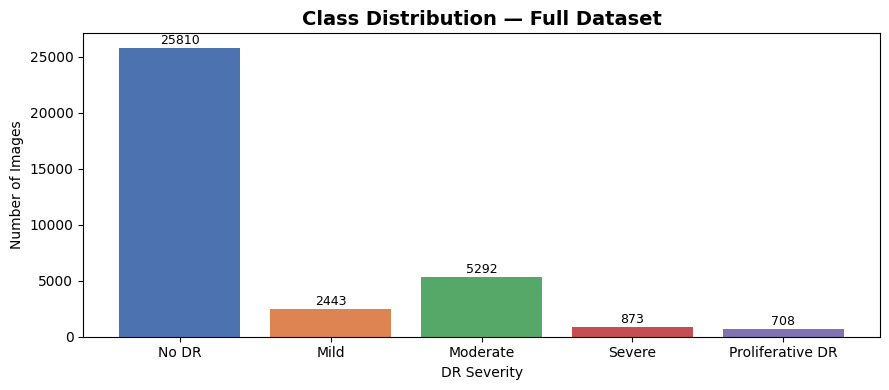

✓ Saved class_distribution.png


In [19]:
labels_df = pd.read_csv(LABELS_CSV)

print("First 10 rows:")
print(labels_df.head(10))
print(f"\nTotal images : {len(labels_df)}")
print("\nClass distribution:")
dist = labels_df["level"].value_counts().sort_index()
for lvl, cnt in dist.items():
    print(f"  Class {lvl} ({CLASS_NAMES[lvl]:18s}): {cnt:6d}  ({cnt/len(labels_df)*100:.1f}%)")

# Plot class distribution
fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(CLASS_NAMES, dist.values,
              color=["#4C72B0","#DD8452","#55A868","#C44E52","#8172B2"])
ax.set_title("Class Distribution — Full Dataset", fontsize=14, fontweight="bold")
ax.set_ylabel("Number of Images")
ax.set_xlabel("DR Severity")
for bar, val in zip(bars, dist.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            str(val), ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.savefig(str(LOG_DIR / "class_distribution.png"), dpi=150)
plt.show()
print("✓ Saved class_distribution.png")


In [20]:
random.seed(SEED)
images_raw = Path(OUTPUT_DIR)

print("Organising images into train / val / test splits ...\n")
for cls in range(NUM_CLASSES):
    imgs = list(labels_df[labels_df["level"] == cls]["image"])
    random.shuffle(imgs)
    n          = len(imgs)
    train_imgs = imgs[:int(n * 0.6)]
    val_imgs   = imgs[int(n * 0.6):int(n * 0.8)]
    test_imgs  = imgs[int(n * 0.8):]

    print(f"  Class {cls} ({CLASS_NAMES[cls]:18s})  "
          f"total={n}  train={len(train_imgs)}  val={len(val_imgs)}  test={len(test_imgs)}")

    for split_name, subset in [("train", train_imgs),
                                ("val",   val_imgs),
                                ("test",  test_imgs)]:
        for img_name in subset:
            src = images_raw / f"{img_name}.jpg"
            dst = DATA_DIR / split_name / str(cls) / f"{img_name}.jpg"
            if src.exists():
                shutil.copy2(str(src), str(dst))

print("\n✓ Dataset organised")

# Verify counts
print("\nVerification:")
for split in ["train", "val", "test"]:
    total = 0
    print(f"  {split.upper()}:")
    for cls in range(NUM_CLASSES):
        n = len(list((DATA_DIR / split / str(cls)).glob("*.jpg")))
        total += n
        print(f"    Class {cls} ({CLASS_NAMES[cls]:18s}): {n:5d}")
    print(f"    {'─'*35}")
    print(f"    Total: {total}\n")


Organising images into train / val / test splits ...

  Class 0 (No DR             )  total=25810  train=15486  val=5162  test=5162
  Class 1 (Mild              )  total=2443  train=1465  val=489  test=489
  Class 2 (Moderate          )  total=5292  train=3175  val=1058  test=1059
  Class 3 (Severe            )  total=873  train=523  val=175  test=175
  Class 4 (Proliferative DR  )  total=708  train=424  val=142  test=142

✓ Dataset organised

Verification:
  TRAIN:
    Class 0 (No DR             ): 15486
    Class 1 (Mild              ):  1465
    Class 2 (Moderate          ):  3175
    Class 3 (Severe            ):   523
    Class 4 (Proliferative DR  ):   424
    ───────────────────────────────────
    Total: 21073

  VAL:
    Class 0 (No DR             ):  5162
    Class 1 (Mild              ):   489
    Class 2 (Moderate          ):  1058
    Class 3 (Severe            ):   175
    Class 4 (Proliferative DR  ):   142
    ───────────────────────────────────
    Total: 7026

  TEST:

In [21]:
class DRDataset(Dataset):
    """PyTorch Dataset for Diabetic Retinopathy graded folder structure."""
    def __init__(self, root_dir, transform=None):
        self.transform = transform
        self.images, self.labels = [], []
        for label in range(NUM_CLASSES):
            cls_dir = Path(root_dir) / str(label)
            if cls_dir.exists():
                for ext in ["*.jpg", "*.jpeg", "*.png"]:
                    for p in cls_dir.glob(ext):
                        self.images.append(str(p))
                        self.labels.append(label)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = Image.open(self.images[idx]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]


# Training: augmentation + normalise
train_transform = transforms.Compose([
    transforms.Resize(TARGET_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Validation / test: only resize + normalise (no stochastic ops)
val_test_transform = transforms.Compose([
    transforms.Resize(TARGET_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

train_dataset = DRDataset(DATA_DIR / "train", train_transform)
val_dataset   = DRDataset(DATA_DIR / "val",   val_test_transform)
test_dataset  = DRDataset(DATA_DIR / "test",  val_test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=4, pin_memory=True)

print(f"  Train : {len(train_dataset):6d} images")
print(f"  Val   : {len(val_dataset):6d} images")
print(f"  Test  : {len(test_dataset):6d} images")

# Sanity check
imgs, lbls = next(iter(train_loader))
print(f"\n  Batch shape : {imgs.shape}   (expect [32, 3, 224, 224])")
print(f"  Label range : {lbls.min().item()} – {lbls.max().item()}")


  Train :  21073 images
  Val   :   7026 images
  Test  :   7027 images

  Batch shape : torch.Size([32, 3, 224, 224])   (expect [32, 3, 224, 224])
  Label range : 0 – 3


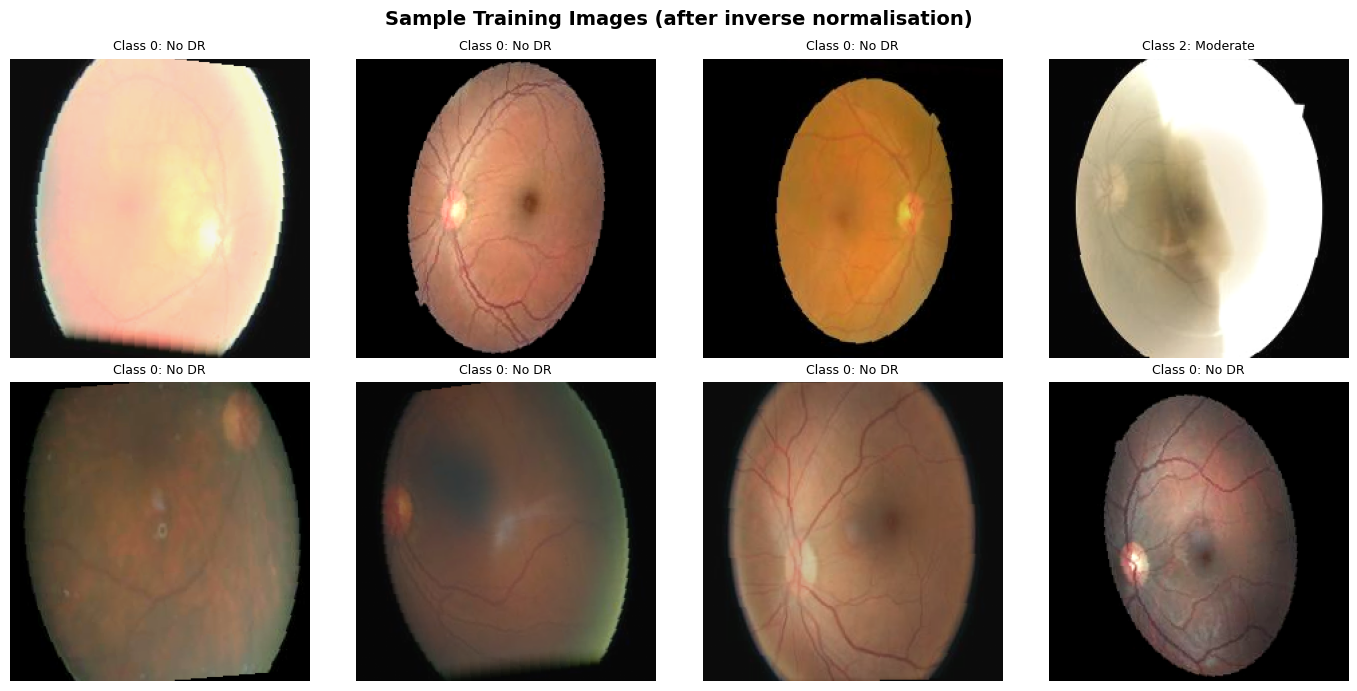

✓ Saved sample_images.png


In [22]:
imgs_raw, lbls_raw = next(iter(train_loader))

# Inverse normalise for display
mean_t = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std_t  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
imgs_show = (imgs_raw[:8] * std_t + mean_t).clamp(0, 1)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
fig.suptitle("Sample Training Images (after inverse normalisation)", fontsize=14, fontweight="bold")

for idx, ax in enumerate(axes.flat):
    img_np = imgs_show[idx].permute(1, 2, 0).numpy()
    ax.imshow(img_np)
    ax.set_title(f"Class {lbls_raw[idx].item()}: {CLASS_NAMES[lbls_raw[idx].item()]}",
                 fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.savefig(str(LOG_DIR / "sample_images.png"), dpi=150)
plt.show()
print("✓ Saved sample_images.png")


In [23]:
model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)

# Freeze all layers first, then unfreeze all for full fine-tuning
for param in model.parameters():
    param.requires_grad = True

# Replace classifier head: 1280 → 5 classes
model.classifier = nn.Sequential(
    nn.Dropout(p=DROPOUT),
    nn.Linear(model.last_channel, NUM_CLASSES)
)
model = model.to(device)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("✓ MobileNetV2 loaded (ImageNet pretrained)")
print(f"  Total parameters     : {total_params/1e6:.2f}M")
print(f"  Trainable parameters : {trainable_params/1e6:.2f}M")
print(f"  Output classes       : {NUM_CLASSES}  {CLASS_NAMES}")


Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 114MB/s] 

✓ MobileNetV2 loaded (ImageNet pretrained)
  Total parameters     : 2.23M
  Trainable parameters : 2.23M
  Output classes       : 5  ['No DR', 'Mild', 'Moderate', 'Severe', 'Proliferative DR']


In [24]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=NUM_EPOCHS,
    eta_min=1e-6
)

print("✓ Training components ready")
print(f"  Loss      : CrossEntropyLoss")
print(f"  Optimiser : AdamW  (lr={LR}, wd={WEIGHT_DECAY})")
print(f"  Scheduler : CosineAnnealingLR  (T_max={NUM_EPOCHS}, eta_min=1e-6)")


✓ Training components ready
  Loss      : CrossEntropyLoss
  Optimiser : AdamW  (lr=0.0001, wd=0.0001)
  Scheduler : CosineAnnealingLR  (T_max=12, eta_min=1e-6)


In [25]:
history = {"train_loss": [], "train_acc": [],
           "val_loss":   [], "val_acc":   []}

best_val_acc      = 0.0
patience_counter  = 0
BEST_MODEL_PATH   = str(CKPT_DIR / "best_model.pth")

print(f"{'='*70}")
print(f"  Training for up to {NUM_EPOCHS} epochs  |  patience = {PATIENCE}")
print(f"  Device: {device}")
print(f"{'='*70}\n")

for epoch in range(1, NUM_EPOCHS + 1):

    # ── Training phase ──────────────────────────────────────
    model.train()
    train_loss = 0.0
    train_preds, train_true = [], []

    for imgs, labels in tqdm(train_loader,
                              desc=f"Epoch {epoch:02d}/{NUM_EPOCHS} [Train]",
                              leave=False):
        imgs, labels = imgs.to(device), labels.to(device)

        outputs = model(imgs)               # Forward pass
        loss    = criterion(outputs, labels)

        optimizer.zero_grad()               # Clear gradients
        loss.backward()                     # Backpropagation
        optimizer.step()                    # Weight update

        train_loss += loss.item()
        _, preds = outputs.max(1)
        train_preds.extend(preds.cpu().numpy())
        train_true.extend(labels.cpu().numpy())

    train_loss /= len(train_loader)
    train_acc   = accuracy_score(train_true, train_preds)

    # ── Validation phase ────────────────────────────────────
    model.eval()
    val_loss = 0.0
    val_preds, val_true = [], []

    with torch.no_grad():
        for imgs, labels in tqdm(val_loader,
                                  desc=f"Epoch {epoch:02d}/{NUM_EPOCHS} [Val]  ",
                                  leave=False):
            imgs, labels = imgs.to(device), labels.to(device)
            outputs  = model(imgs)
            loss     = criterion(outputs, labels)
            val_loss += loss.item()
            _, preds = outputs.max(1)
            val_preds.extend(preds.cpu().numpy())
            val_true.extend(labels.cpu().numpy())

    val_loss /= len(val_loader)
    val_acc   = accuracy_score(val_true, val_preds)

    # LR step
    scheduler.step()
    current_lr = scheduler.get_last_lr()[0]

    # Record history
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    # Print epoch summary
    improved = val_acc > best_val_acc
    tag      = "  ← best ✓" if improved else ""
    print(f"Epoch {epoch:02d}/{NUM_EPOCHS}  "
          f"TrLoss={train_loss:.4f}  TrAcc={train_acc*100:.2f}%  |  "
          f"VlLoss={val_loss:.4f}  VlAcc={val_acc*100:.2f}%  "
          f"LR={current_lr:.2e}{tag}")

    # Checkpoint & early stopping
    if improved:
        best_val_acc     = val_acc
        patience_counter = 0
        torch.save(model.state_dict(), BEST_MODEL_PATH)
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"\n  Early stopping — no improvement for {PATIENCE} epochs.")
            break

print(f"\n{'='*70}")
print(f"  Training complete  |  Best val accuracy: {best_val_acc*100:.2f}%")
print(f"  Checkpoint saved to: {BEST_MODEL_PATH}")
print(f"{'='*70}")


  Training for up to 12 epochs  |  patience = 10
  Device: cuda



Epoch 01/12  TrLoss=0.7929  TrAcc=73.81%  |  VlLoss=0.7082  VlAcc=76.17%  LR=9.83e-05  ← best ✓


Epoch 02/12  TrLoss=0.7210  TrAcc=75.64%  |  VlLoss=0.7346  VlAcc=74.55%  LR=9.34e-05


Epoch 03/12  TrLoss=0.6899  TrAcc=76.89%  |  VlLoss=0.6860  VlAcc=76.83%  LR=8.55e-05  ← best ✓


Epoch 04/12  TrLoss=0.6675  TrAcc=77.33%  |  VlLoss=0.7020  VlAcc=76.79%  LR=7.52e-05


...

Epoch 08/12  TrLoss=0.5887  TrAcc=79.55%  |  VlLoss=0.6608  VlAcc=77.64%  LR=2.58e-05


Epoch 09/12  TrLoss=0.5653  TrAcc=80.40%  |  VlLoss=0.6744  VlAcc=77.18%  LR=1.55e-05


Epoch 10/12  TrLoss=0.5485  TrAcc=80.73%  |  VlLoss=0.6709  VlAcc=77.84%  LR=7.63e-06


Epoch 11/12  TrLoss=0.5351  TrAcc=81.25%  |  VlLoss=0.6760  VlAcc=77.75%  LR=2.69e-06


Epoch 12/12  TrLoss=0.5254  TrAcc=81.27%  |  VlLoss=0.6768  VlAcc=77.80%  LR=1.00e-06

  Training complete  |  Best val accuracy: 78.11%
  Checkpoint saved to: /kaggle/working/SplitDATA/checkpoints/best_model.pth


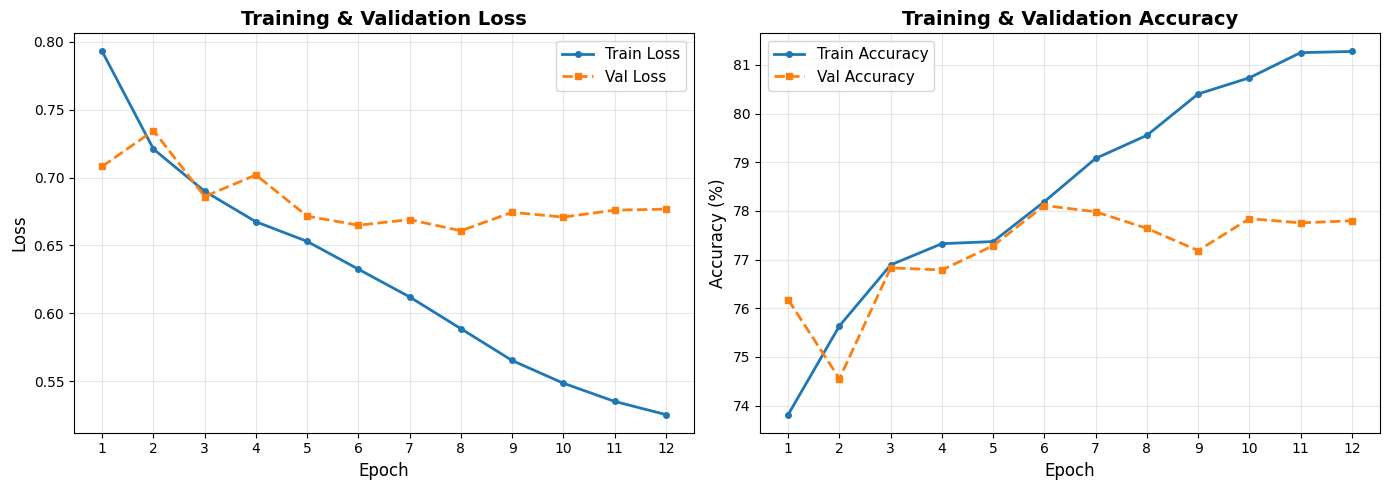

✓ Saved training_curves.png


In [26]:
epochs_ran = list(range(1, len(history["train_loss"]) + 1))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(epochs_ran, history["train_loss"],
             label="Train Loss", marker="o", markersize=4, linewidth=2)
axes[0].plot(epochs_ran, history["val_loss"],
             label="Val Loss",   marker="s", markersize=4, linewidth=2, linestyle="--")
axes[0].set_xlabel("Epoch", fontsize=12)
axes[0].set_ylabel("Loss",  fontsize=12)
axes[0].set_title("Training & Validation Loss", fontsize=14, fontweight="bold")
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(epochs_ran)

# Accuracy
train_acc_pct = [a * 100 for a in history["train_acc"]]
val_acc_pct   = [a * 100 for a in history["val_acc"]]
axes[1].plot(epochs_ran, train_acc_pct,
             label="Train Accuracy", marker="o", markersize=4, linewidth=2)
axes[1].plot(epochs_ran, val_acc_pct,
             label="Val Accuracy",   marker="s", markersize=4, linewidth=2, linestyle="--")
axes[1].set_xlabel("Epoch",        fontsize=12)
axes[1].set_ylabel("Accuracy (%)", fontsize=12)
axes[1].set_title("Training & Validation Accuracy", fontsize=14, fontweight="bold")
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(epochs_ran)

plt.tight_layout()
plt.savefig(str(LOG_DIR / "training_curves.png"), dpi=300, bbox_inches="tight")
plt.show()
print("✓ Saved training_curves.png")


In [27]:
model_eval = models.mobilenet_v2(weights=None)
model_eval.classifier = nn.Sequential(
    nn.Dropout(p=DROPOUT),
    nn.Linear(model_eval.last_channel, NUM_CLASSES)
)
model_eval.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))
model_eval = model_eval.to(device)
model_eval.eval()

test_preds, test_true = [], []

with torch.no_grad():
    for imgs, labels in tqdm(test_loader, desc="Testing"):
        imgs   = imgs.to(device)
        outputs = model_eval(imgs)
        _, preds = outputs.max(1)
        test_preds.extend(preds.cpu().numpy())
        test_true.extend(labels.numpy())

test_acc = accuracy_score(test_true, test_preds)
cm       = confusion_matrix(test_true, test_preds)

print(f"\n{'='*60}")
print(f"  TEST RESULTS")
print(f"{'='*60}")
print(f"  Overall Accuracy : {test_acc*100:.2f}%\n")

print("  Per-Class Accuracy:")
for i in range(NUM_CLASSES):
    cls_acc = cm[i, i] / cm[i].sum() * 100 if cm[i].sum() > 0 else 0.0
    print(f"    Class {i} ({CLASS_NAMES[i]:18s}): {cls_acc:.2f}%")

print(f"\n  Classification Report:\n")
print(classification_report(test_true, test_preds,
                             target_names=CLASS_NAMES,
                             digits=4))


Testing: 100%|██████████| 220/220 [00:07<00:00, 28.73it/s]


  TEST RESULTS
  Overall Accuracy : 78.31%

  Per-Class Accuracy:
    Class 0 (No DR             ): 97.40%
    Class 1 (Mild              ): 0.00%
    Class 2 (Moderate          ): 33.62%
    Class 3 (Severe            ): 30.86%
    Class 4 (Proliferative DR  ): 45.77%

  Classification Report:

                  precision    recall  f1-score   support

           No DR     0.8110    0.9740    0.8851      5162
            Mild     0.0000    0.0000    0.0000       489
        Moderate     0.5742    0.3362    0.4241      1059
          Severe     0.5870    0.3086    0.4045       175
Proliferative DR     0.5652    0.4577    0.5058       142

        accuracy                         0.7831      7027
       macro avg     0.5075    0.4153    0.4439      7027
    weighted avg     0.7083    0.7831    0.7344      7027




/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


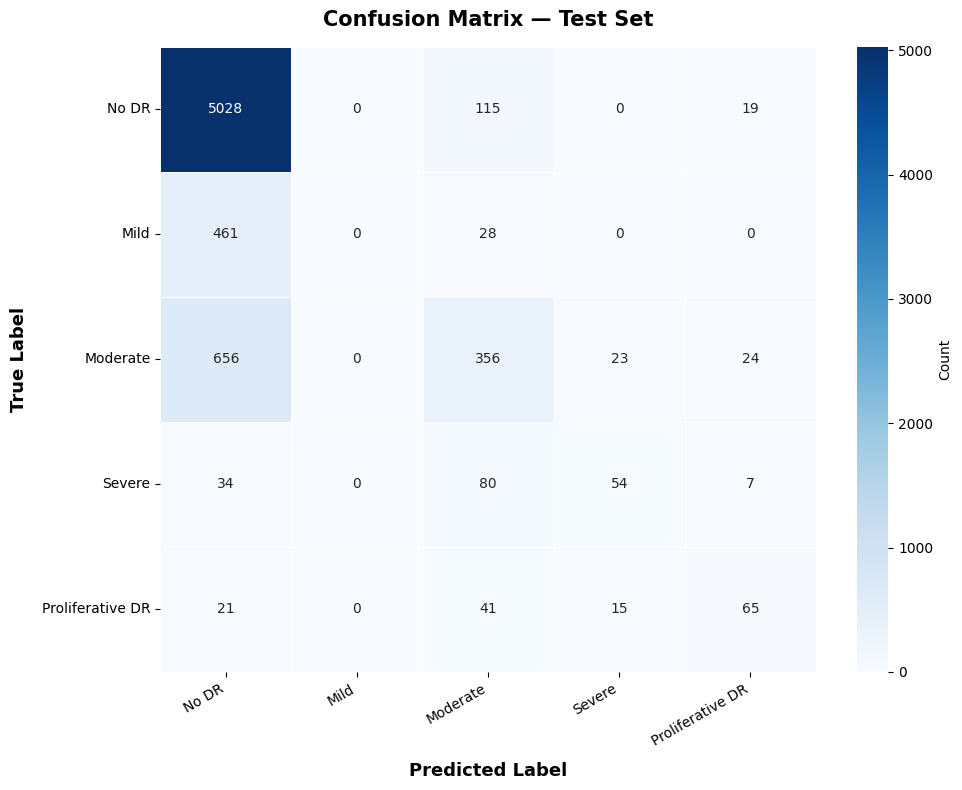

✓ Saved confusion_matrix.png


In [28]:
fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    cbar_kws={"label": "Count"},
    linewidths=0.5,
    linecolor="white",
    ax=ax
)

ax.set_xlabel("Predicted Label", fontsize=13, fontweight="bold", labelpad=10)
ax.set_ylabel("True Label",      fontsize=13, fontweight="bold", labelpad=10)
ax.set_title("Confusion Matrix — Test Set",
             fontsize=15, fontweight="bold", pad=15)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right", fontsize=10)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0,  fontsize=10)

plt.tight_layout()
plt.savefig(str(LOG_DIR / "confusion_matrix.png"), dpi=300, bbox_inches="tight")
plt.show()
print("✓ Saved confusion_matrix.png")


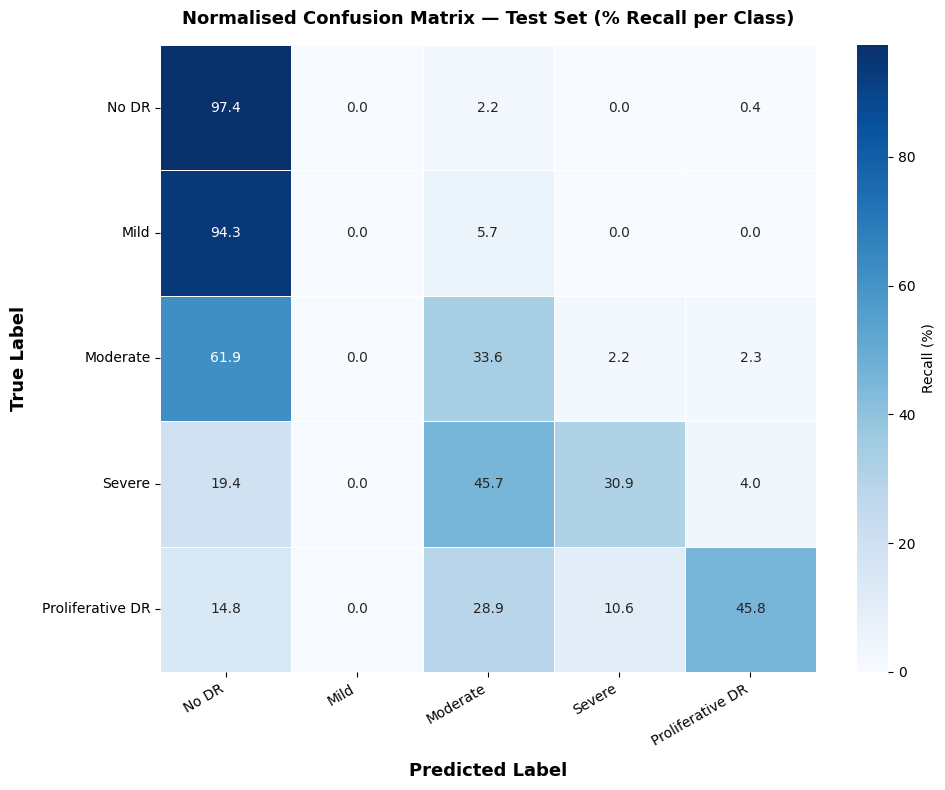

✓ Saved confusion_matrix_normalised.png


In [29]:
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    cbar_kws={"label": "Recall (%)"},
    linewidths=0.5,
    linecolor="white",
    ax=ax
)
ax.set_xlabel("Predicted Label", fontsize=13, fontweight="bold", labelpad=10)
ax.set_ylabel("True Label",      fontsize=13, fontweight="bold", labelpad=10)
ax.set_title("Normalised Confusion Matrix — Test Set (% Recall per Class)",
             fontsize=13, fontweight="bold", pad=15)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right", fontsize=10)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0,  fontsize=10)

plt.tight_layout()
plt.savefig(str(LOG_DIR / "confusion_matrix_normalised.png"), dpi=300, bbox_inches="tight")
plt.show()
print("✓ Saved confusion_matrix_normalised.png")


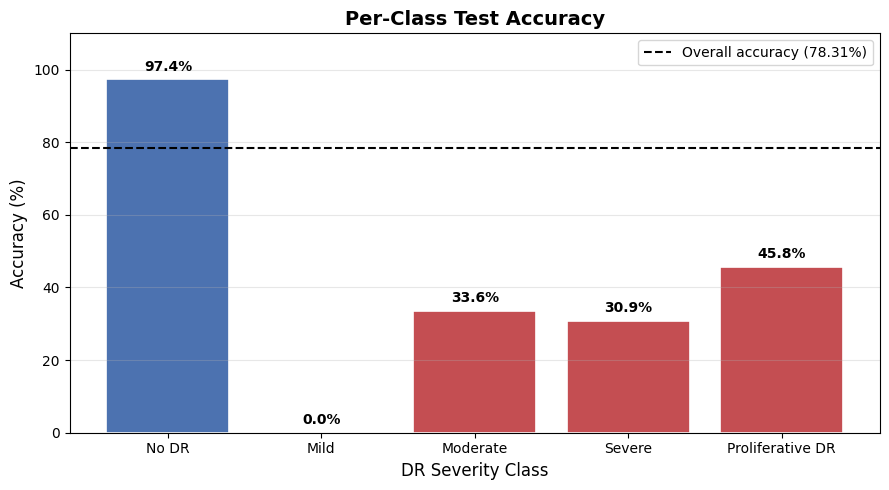

✓ Saved per_class_accuracy.png


In [30]:
per_class_acc = [cm[i, i] / cm[i].sum() * 100 if cm[i].sum() > 0 else 0.0
                 for i in range(NUM_CLASSES)]

colours = ["#4C72B0" if a >= 70 else "#DD8452" if a >= 50 else "#C44E52"
           for a in per_class_acc]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(CLASS_NAMES, per_class_acc, color=colours, edgecolor="white", linewidth=1.2)
ax.axhline(test_acc * 100, color="black", linestyle="--", linewidth=1.5,
           label=f"Overall accuracy ({test_acc*100:.2f}%)")
ax.set_ylim(0, 110)
ax.set_ylabel("Accuracy (%)", fontsize=12)
ax.set_xlabel("DR Severity Class", fontsize=12)
ax.set_title("Per-Class Test Accuracy", fontsize=14, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.3)

for bar, val in zip(bars, per_class_acc):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
            f"{val:.1f}%", ha="center", va="bottom", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.savefig(str(LOG_DIR / "per_class_accuracy.png"), dpi=300, bbox_inches="tight")
plt.show()
print("✓ Saved per_class_accuracy.png")





In [31]:
print("\n" + "="*60)
print("  FINAL SUMMARY")
print("="*60)
print(f"  Model         : MobileNetV2 (ImageNet pretrained)")
print(f"  Epochs run    : {len(history['train_loss'])}")
print(f"  Best val acc  : {best_val_acc*100:.2f}%")
print(f"  Test accuracy : {test_acc*100:.2f}%")
print(f"\n  Saved outputs in {LOG_DIR}:")
for f in sorted(LOG_DIR.glob("*.png")):
    print(f"    {f.name}")
print(f"\n  Best checkpoint : {BEST_MODEL_PATH}")
print("="*60)



  FINAL SUMMARY
  Model         : MobileNetV2 (ImageNet pretrained)
  Epochs run    : 12
  Best val acc  : 78.11%
  Test accuracy : 78.31%

  Saved outputs in /kaggle/working/SplitDATA/logs:
    class_distribution.png
    confusion_matrix.png
    confusion_matrix_normalised.png
    per_class_accuracy.png
    sample_images.png
    training_curves.png

  Best checkpoint : /kaggle/working/SplitDATA/checkpoints/best_model.pth
